# SPH6004-Individual-Project

In this study MIMIC – IV database is used to develop a predictive model using machine leaning to forecast the chance of patient mortality in ICU.

# Missing values
- Calculate missing % per feature
- To take decision on whether to impute, drop, or flag the data
    - Above 60% missing  →  Drop the feature
    - 20% – 60%          →  Impute with median (continuous) or mode (categorical)
    - Less than 20%      →  Impute with median / mode
    - 0%                 →  No action needed

In [ ]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv('Assignment1_mimic dataset.csv')

# Excluding leakage and IDs
exclude = ['subject_id', 'hadm_id', 'stay_id', 'intime', 'outtime', 'deathtime', 'los', 'hospital_expire_flag', 'icu_death_flag']

feature = [col for col in df.columns if col not in exclude]

# Missing value table
total_rows = len(df)

missing_report = pd.DataFrame({
    'Missing_Count' : df[feature].isnull().sum(),
    'Missing_%'     : (df[feature].isnull().sum() / total_rows * 100).round(2)
}).sort_values('Missing_%', ascending=False)

# Show only features with missing values
missing_report = missing_report[missing_report['Missing_Count'] > 0]
print(missing_report)

missing_report.to_excel("missing_value_report.xlsx")

                              Missing_Count  Missing_%
thrombin_max                          65332      99.95
thrombin_min                          65332      99.95
ggt_min                               65261      99.84
ggt_max                               65261      99.84
globulin_max                          65203      99.75
...                                     ...        ...
sofa2_liver_24h_max                       1       0.00
sofa2_cns_24h_max                         1       0.00
sofa2_respiration_24h_max                 1       0.00
sofa2_cardiovascular_24h_max              1       0.00
sofa2_renal_24h_max                       1       0.00

[126 rows x 2 columns]


# Updating the report based on missing value report
Step 1: Removed columns with more than 50% missing data

In [ ]:
import pandas as pd

print("Original dataset shape:", df.shape)

# Identifiers
id_col = ['hadm_id', 'stay_id', 'subject_id']

# Time variables
time_col = ['intime', 'outtime', 'deathtime']

# Domain Knowledge
domain_col = ['last_careunit', 'gcs_motor', 'gcs_verbal', 'gcs_eyes', 'temperature_mean', 'glucose_mean',
               'resp_rate_mean', 'spo2_mean', 'mbp_mean', 'sbp_mean', 'dbp_mean', 'heart_rate_mean']

# Leakage variables
dataleak_col = ['los', 'hospital_expire_flag']

# Columns with high missing values
high_missing_col = [
    'thrombin_min','thrombin_max','ggt_min','ggt_max','globulin_min','globulin_max',
    'd_dimer_min','d_dimer_max','total_protein_min','total_protein_max',
    'bilirubin_indirect_min','bilirubin_indirect_max','amylase_min','amylase_max',
    'bilirubin_direct_min','bilirubin_direct_max','nrbc_min','nrbc_max',
    'atyps_min','atyps_max','metas_min','metas_max','bands_min','bands_max',
    'imm_granulocytes_min','imm_granulocytes_max','fibrinogen_min','fibrinogen_max',
    'ck_cpk_min','ck_cpk_max','ck_mb_min','ck_mb_max','ld_ldh_min','ld_ldh_max',
    'albumin_min','albumin_max','abs_neutrophils_min','abs_neutrophils_max',
    'abs_monocytes_min','abs_monocytes_max','abs_eosinophils_min','abs_eosinophils_max',
    'abs_basophils_min','abs_basophils_max','abs_lymphocytes_min','abs_lymphocytes_max',
    'bilirubin_total_min','bilirubin_total_max','alp_min','alp_max','alt_min','alt_max',
    'ast_min','ast_max','ptt_min','ptt_max','pt_min','pt_max','inr_min','inr_max',
    'calcium_min','calcium_max','aniongap_min','aniongap_max','bicarbonate_min','bicarbonate_max',
    'chloride_min','chloride_max','potassium_min','potassium_max','sodium_min','sodium_max',
    'platelets_min','platelets_max','hemoglobin_min','hemoglobin_max','wbc_min','wbc_max',
    'creatinine_min','creatinine_max','bun_min','bun_max','hematocrit_min','hematocrit_max',
    'so2_min','so2_max','po2_min','po2_max'
]


drop_cols = id_col + time_col + dataleak_col + high_missing_col + domain_col
df_updated = df.drop(columns=drop_cols, errors='ignore')

print("Updated dataset shape:", df_updated.shape)
print("Columns removed:", len(drop_cols))

# updated dataset
df_updated.to_csv("Assignment1_mimic_data_updated.csv", index=False)
print("Cleaned dataset saved as Assignment1_mimic_data_updated.csv")

Original dataset shape: (65366, 140)
Updated dataset shape: (65366, 32)
Columns removed: 108
Cleaned dataset saved as Assignment1_mimic_data_updated.csv


Step 2: Grouping certain categorical variables

In [ ]:
#race
def group_race(race):
    race = str(race).upper()
    if "WHITE" in race or "PORTUGUESE" in race:
        return 'White'
    elif 'BLACK' in race or 'AFRICAN' in race:
        return 'Black'
    elif 'HISPANIC' in race or 'LATINO' in race:
        return 'Hispanic'
    elif 'ASIAN' in race:                        
        return 'Asian'
    else:                                        
        return 'Other'

df_updated['race'] = df_updated['race'].apply(group_race)

#language
def group_lan(language):
    if pd.isna(language):
        return 'Non-English'
    language = str(language).upper()

    if "ENGLISH" in language:
        return 'English'
    else:
        return 'Non-English'

df_updated['language'] = df_updated['language'].apply(group_lan)

#first care unit
def group_careunit(unit):
    if pd.isna(unit):
        return 'Other'
    unit = str(unit).upper()          
    if "MICU" in unit or "MEDICINE" in unit:
        return "Medical ICU"
    elif "SICU" in unit or "SURGERY" in unit or "TRAUMA" in unit:
        return "Surgical ICU"
    elif "CCU" in unit or "CVICU" in unit:
        return "Cardiac ICU"         
    elif "NEURO" in unit:
        return "Neuro ICU"
    elif "PACU" in unit or "STEPDOWN" in unit or "INTERMEDIATE" in unit:
        return "Stepdown/Recovery"
    elif "MED/SURG" in unit or "INTENSIVE CARE UNIT" in unit:
        return "General ICU"
    else:
        return "Other"

df_updated['first_careunit'] = df_updated['first_careunit'].apply(group_careunit)

#marital ststus
def group_marital(status):
    if pd.isna(status):
        return 0
    status = str(status).upper()
    if 'MARRIED' in status or 'PARTNER' in status:
        return 'Support'   # has partner support
    else:
        return 'Less Support'   # no partner support

df_updated['marital_status'] = df_updated['marital_status'].apply(group_marital)


Step 3: Separate features and target

In [ ]:
# creating x and y data frame
x = df_updated.drop(columns=['icu_death_flag'])
y = df_updated['icu_death_flag']

#seperation of features as categorical and continuous
categorical_col = ['first_careunit', 'insurance', 'race']
continuous_col = [col for col in x.columns if col not in categorical_col ]

Step 4: Split the dataset (X, Y) for train and test

In [ ]:
#train and test dataset
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Step 5: Imputation for variables (fit on train only)

In [ ]:
#binary value for gender
x_train['gender'] = x_train['gender'].map({'M': 1, 'F': 0})
x_test['gender']  = x_test['gender'].map({'M': 1, 'F': 0})

#binary value for language
x_train['language'] = x_train['language'].map({'English': 1, 'Non-English': 0})
x_test['language']  = x_test['language'].map({'English': 1, 'Non-English': 0})

#binary value for marital status
x_train['marital_status'] = x_train['marital_status'].map({'Support': 1, 'Less Support': 0})
x_test['marital_status']  = x_test['marital_status'].map({'Support': 1, 'Less Support': 0})

#imputing median
continuous_imputer = SimpleImputer(strategy='median')

x_train[continuous_col] = continuous_imputer.fit_transform(x_train[continuous_col])
x_test[continuous_col]  = continuous_imputer.transform(x_test[continuous_col])

#imputing mode
categorical_imputer = SimpleImputer(strategy='most_frequent')

x_train[categorical_col] = categorical_imputer.fit_transform(x_train[categorical_col])
x_test[categorical_col]  = categorical_imputer.transform(x_test[categorical_col])


Step 6: Encode and scaler continuous variables

In [ ]:
from category_encoders import TargetEncoder
from sklearn.preprocessing import StandardScaler

# imputing numerical values for categorical variables 
other_col = ['first_careunit', 'insurance', 'race']

encoder = TargetEncoder(cols=other_col)
x_train[other_col] = encoder.fit_transform(x_train[other_col], y_train)
x_test[other_col]  = encoder.transform(x_test[other_col])

binary_col   = ['gender', 'language', 'marital_status', 'gcs_unable']
scale  = [col for col in x_train.columns if col not in binary_col]

# scaling variables apart from binary data
scaler = StandardScaler()

x_train[scale] = scaler.fit_transform(x_train[scale])
x_test[scale]  = scaler.transform(x_test[scale])



# Summary

In [21]:
print("\nPreprocessing complete")
print(f"Final feature count : {x_train.shape[1]}")
print(f"X_train shape       : {x_train.shape}")
print(f"X_test shape        : {x_test.shape}")
print(f"Missing in X_train  : {x_train.isnull().sum().sum()}")
print(f"Missing in X_test   : {x_test.isnull().sum().sum()}")
print("\nThe ICU mortality rate in test and train")
print(f"Death rate (train)  : {y_train.mean():.2%}")
print(f"Death rate (test)   : {y_test.mean():.2%}")


Preprocessing complete
Final feature count : 31
X_train shape       : (52292, 31)
X_test shape        : (13074, 31)
Missing in X_train  : 0
Missing in X_test   : 0

The ICU mortality rate in test and train
Death rate (train)  : 8.68%
Death rate (test)   : 8.67%


In [ ]:
#column available in x_train
print(f"Total features: {x_train.shape[1]}")
print("\nAll columns in x_train:")
for i, col in enumerate(x_train.columns, 1):
    print(f"{col}")

Total features: 31

All columns in x_train:
first_careunit
insurance
language
race
marital_status
age
gender
sofa2_respiration_24h_max
sofa2_cardiovascular_24h_max
sofa2_coagulation_24h_max
sofa2_liver_24h_max
sofa2_renal_24h_max
sofa2_cns_24h_max
heart_rate_min
heart_rate_max
sbp_min
sbp_max
dbp_min
dbp_max
mbp_min
mbp_max
resp_rate_min
resp_rate_max
temperature_min
temperature_max
spo2_min
spo2_max
glucose_min
glucose_max
gcs_min
gcs_unable


# Featue Selection
Feature1 ---> L1+L2 Regularization (Elastic Net Logistic Regression)

In [28]:
from sklearn.linear_model import LogisticRegression

elasticnet = LogisticRegression(
    solver="saga",           # elastic net
    l1_ratio=0.5,            # 0.5 so there is balance between L1 and L2
    C=1.0,                   # regularization strength
    class_weight="balanced", # to handle class imbalance
    max_iter=5000,
    random_state=42
)

# Training model
elasticnet.fit(x_train, y_train)

# Feature Coefficients
coef = elasticnet.coef_.flatten() # convert from 2D to 3D array # naming convention 

#create a table for features where coefficients are not zero
elasticnet_results = pd.DataFrame({
    "Feature": x_train.columns,
    "Coefficient": np.abs(coef),
    "Selected": coef != 0
}).sort_values("Coefficient", ascending=False)


print("\nElastic Net Features\n")
print(elasticnet_results)

elasticnet_results.to_csv("feature_selection_elasticnet.csv", index=False)
print("\nSaved results to feature_selection_elasticnet.csv")



Elastic Net Features

                         Feature  Coefficient  Selected
30                    gcs_unable     2.102652      True
29                       gcs_min     0.583699      True
0                 first_careunit     0.500613      True
5                            age     0.460377      True
25                      spo2_min     0.386783      True
21                 resp_rate_min     0.300034      True
14                heart_rate_max     0.294567      True
10           sofa2_liver_24h_max     0.285558      True
3                           race     0.268544      True
11           sofa2_renal_24h_max     0.240032      True
27                   glucose_min     0.229997      True
15                       sbp_min     0.224499      True
23               temperature_min     0.209359      True
22                 resp_rate_max     0.201780      True
19                       mbp_min     0.145467      True
26                      spo2_max     0.144426      True
4                 marital

Feature 2 ---> Bidirectional Stepwise Selection

Performs bidirectional stepwise feature selection using AUC-ROC.

- Forward step  : adds the feature that improves AUC the most.
- Backward step : removes features that improve AUC when excluded.

Stops when no further improvement is observed.

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score


def bidirectional_stepwise_selection(
        x_train,
        y_train,
        max_features=x_train.shape[1],
        improvement_threshold=0.001):

    def evaluate(features):
        if not features:
            return 0

        model = LogisticRegression(
            solver="lbfgs",
            class_weight="balanced", # handle class imbalance
            max_iter=1000,           #100 failed
            random_state=42
        )

        model.fit(x_train[features], y_train)
        y_prob = model.predict_proba(x_train[features])[:, 1] #to get probability of people survived

        return roc_auc_score(y_train, y_prob)


    remaining = list(x_train.columns)
    selected = []
    best_auc = 0
    step = 0
    log = []

    #audit trial or output of  bidirectional stepwise
    print("\nBidirectional Stepwise Selection\n")
    print(f"{'Step':<5} {'Action':<8} {'Feature':<25} {'AUC':<8} {'Change'}") #for clean visualization
    
    while True:
        step += 1

        # Forward step
        best_add_feature = None
        best_add_auc = best_auc

        for feature in remaining:
            auc = evaluate(selected + [feature])

            if auc > best_add_auc:
                best_add_auc = auc
                best_add_feature = feature

        # Backward step
        best_remove_feature = None
        best_remove_auc = best_auc

        for feature in selected:
            choose = [f for f in selected if f != feature]
            auc = evaluate(choose)

            if auc > best_remove_auc:
                best_remove_auc = auc
                best_remove_feature = feature

        add_gain = best_add_auc - best_auc
        remove_gain = best_remove_auc - best_auc

        # Stop condition
        if add_gain < improvement_threshold and remove_gain < improvement_threshold:
            print("\nStopping: no further improvement")
            break

        # add or remove 
        if add_gain >= remove_gain and best_add_feature:

            selected.append(best_add_feature)
            remaining.remove(best_add_feature)

            action = "ADD"
            feature = best_add_feature
            best_auc = best_add_auc
            change = add_gain

        else:

            selected.remove(best_remove_feature)
            remaining.append(best_remove_feature)

            action = "REMOVE"
            feature = best_remove_feature
            best_auc = best_remove_auc
            change = remove_gain

        print(f"{step:<5} {action:<8} {feature:<25} {best_auc:<8.4f} {change:+.4f}")

        log.append({
            "Step": step,
            "Action": action,
            "Feature": feature,
            "AUC": round(best_auc, 4),
            "Change": round(change, 4)
        })
        #stopping criteria
        if len(selected) >= max_features:
            print(f"\nStopping: max features ({max_features}) reached")
            break

    return selected, pd.DataFrame(log)


# Run feature selection
stepwise_features, stepwise_log = bidirectional_stepwise_selection(x_train, y_train)

# Save results
stepwise_log.to_csv("feature_selection_stepwise.csv", index=False)

print("\nSaved results to feature_selection_stepwise.csv")


Bidirectional Stepwise Selection

Step  Action   Feature                   AUC      Change
1     ADD      sbp_min                   0.7095   +0.7095
2     ADD      gcs_unable                0.7471   +0.0376
3     ADD      gcs_min                   0.7855   +0.0384
4     ADD      spo2_min                  0.8159   +0.0304
5     ADD      resp_rate_min             0.8308   +0.0148
6     ADD      sofa2_liver_24h_max       0.8423   +0.0115
7     ADD      age                       0.8502   +0.0080
8     ADD      first_careunit            0.8595   +0.0093
9     ADD      sofa2_renal_24h_max       0.8644   +0.0049
10    ADD      race                      0.8688   +0.0044
11    ADD      heart_rate_max            0.8732   +0.0044
12    ADD      temperature_min           0.8765   +0.0034
13    ADD      glucose_min               0.8797   +0.0032
14    ADD      resp_rate_max             0.8812   +0.0015

Stopping: no further improvement

Saved results to feature_selection_stepwise.csv


Feature 3 ---> Genetic Algorithm using AUC-ROC

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

def genetic_algorithm_selection(
        x_train,
        y_train,
        population_size=20,
        n_generations=30,
        mutation_rate=0.1,
        random_state=42):

    np.random.seed(random_state)

    features = list(x_train.columns)
    n_features = len(features)

    # Fitness function
    def fitness(variable):

        selected = [features[i] for i in range(n_features) if variable[i] == 1]

        if not selected:
            return 0

        model = LogisticRegression(
            solver="lbfgs",
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        )

        model.fit(x_train[selected], y_train)
        y_prob = model.predict_proba(x_train[selected])[:, 1]

        return roc_auc_score(y_train, y_prob)

    # initate population
    population = [np.random.randint(0, 2, n_features) for _ in range(population_size)]

    best_variable = None
    best_auc = 0
    log = []

    print("\nGenetic Algorithm Feature Selection\n")
    print(f"{'Gen':<6}{'Best AUC':<12}{'Avg AUC':<12}{'Features'}") ##for clean visualization
    
    for generation in range(1, n_generations + 1):

        scores = [fitness(ch) for ch in population]

        best_idx = np.argmax(scores)
        gen_best_auc = scores[best_idx]

        if gen_best_auc > best_auc:
            best_auc = gen_best_auc
            best_variable = population[best_idx].copy()

        avg_auc = np.mean(scores)
        n_selected = int(best_variable.sum())

        log.append({
            "Generation": generation,
            "Best_AUC": round(best_auc, 4),
            "Avg_AUC": round(avg_auc, 4),
            "Features_in_Best": n_selected
        })

        print(f"{generation:<6}{best_auc:<12.4f}{avg_auc:<12.4f}{n_selected}")

        # Selection (top 50%)
        sorted_idx = np.argsort(scores)[::-1]
        survivors = [population[i] for i in sorted_idx[:population_size // 2]]

        # Crossover
        children = []
        np.random.shuffle(survivors)

        for i in range(0, len(survivors) - 1, 2):

            p1, p2 = survivors[i], survivors[i + 1]
            point = np.random.randint(1, n_features)

            c1 = np.concatenate([p1[:point], p2[point:]])
            c2 = np.concatenate([p2[:point], p1[point:]])

            children.extend([c1, c2])

        # Mutation
        for ch in children:
            for g in range(n_features):
                if np.random.random() < mutation_rate:
                    ch[g] = 1 - ch[g]

        population = survivors + children

        while len(population) < population_size:
            population.append(np.random.randint(0, 2, n_features))

    # Extract selected features
    genetic_features = [
        features[i] for i in range(n_features) if best_variable[i] == 1
    ]

    return genetic_features, pd.DataFrame(log)


# Run genetic algorithm
genetic_features, genetic_log = genetic_algorithm_selection(x_train, y_train)

print("\n Selected features")
# Results
for i, f in enumerate(genetic_features, 1):
    print(f"{f}")

print(f"\nTotal features selected: {len(genetic_features)}")


# Save results
genetic_log.to_csv("feature_selection_genetic.csv", index=False)
print("\nSaved results to feature_selection_genetic.csv")


Genetic Algorithm Feature Selection

Gen   Best AUC    Avg AUC     Features
1     0.8673      0.8145      17
2     0.8719      0.8358      17
3     0.8719      0.8499      17
4     0.8731      0.8607      20
5     0.8758      0.8660      24
6     0.8758      0.8616      24
7     0.8775      0.8681      18
8     0.8814      0.8660      23
9     0.8814      0.8685      23
10    0.8814      0.8690      23
11    0.8814      0.8723      23
12    0.8814      0.8716      23
13    0.8814      0.8717      23
14    0.8814      0.8759      23
15    0.8814      0.8732      23
16    0.8829      0.8778      24
17    0.8829      0.8771      24
18    0.8829      0.8736      24
19    0.8829      0.8708      24
20    0.8829      0.8769      24
21    0.8829      0.8791      24
22    0.8829      0.8761      24
23    0.8829      0.8751      24
24    0.8829      0.8766      24
25    0.8829      0.8754      24
26    0.8833      0.8749      25
27    0.8833      0.8742      25
28    0.8833      0.8794      25

Feature 4: Random forest

Combining all the feature selected to finalize

In [32]:
# listing features selected by each method

elasticnet_features = list(x_train.columns)

stepwise_features = [
    'sbp_min','gcs_unable','gcs_min','spo2_min','resp_rate_min',
    'sofa2_liver_24h_max','age','first_careunit','sofa2_renal_24h_max',
    'race','heart_rate_max','temperature_min','glucose_min','resp_rate_max'
]

genetic_features = [
    'first_careunit','language','race','age',
    'sofa2_respiration_24h_max','sofa2_cardiovascular_24h_max',
    'sofa2_liver_24h_max','sofa2_renal_24h_max','sofa2_cns_24h_max',
    'heart_rate_min','heart_rate_max','sbp_min','dbp_min','dbp_max',
    'mbp_min','resp_rate_min','resp_rate_max','temperature_min',
    'temperature_max','spo2_min','spo2_max','glucose_min','glucose_max',
    'gcs_min','gcs_unable'
]

# Comparison table
comparison_df = pd.DataFrame({"Feature": x_train.columns})

comparison_df["ElasticNet"]      = comparison_df["Feature"].isin(elasticnet_features)
comparison_df["Stepwise"]        = comparison_df["Feature"].isin(stepwise_features)
comparison_df["Genetic"]         = comparison_df["Feature"].isin(genetic_features)

comparison_df["Votes"] = comparison_df[["ElasticNet","Stepwise","Genetic"]].sum(axis=1)

comparison_df = comparison_df.sort_values("Votes", ascending=False)

print("\nFeature Selection Consensus\n")
print(comparison_df)


# Consensus groups
selected_all_3  = comparison_df.loc[comparison_df["Votes"] == 3, "Feature"].tolist()
selected_2_of_3 = comparison_df.loc[comparison_df["Votes"] == 2, "Feature"].tolist()
selected_1_of_3 = comparison_df.loc[comparison_df["Votes"] == 1, "Feature"].tolist()


print(f"\nSelected by all 3 methods: {len(selected_all_3)}")
print(selected_all_3)

print(f"\nSelected by 2 method: {len(selected_2_of_3)}")
print(selected_2_of_3)

print(f"\nSelected by only 1 method: {len(selected_1_of_3)}")
print(selected_1_of_3)

# Final feature set 
final_features = selected_all_3 

print(f"\nFinal feature set: {len(final_features)} features")

# Apply to datasets
x_train_final = x_train[final_features]
x_test_final  = x_test[final_features]

print("x_train_final:", x_train_final.shape)
print("x_test_final :", x_test_final.shape)


Feature Selection Consensus

                         Feature  ElasticNet  Stepwise  Genetic  Votes
0                 first_careunit        True      True     True      3
5                            age        True      True     True      3
3                           race        True      True     True      3
11           sofa2_renal_24h_max        True      True     True      3
14                heart_rate_max        True      True     True      3
10           sofa2_liver_24h_max        True      True     True      3
15                       sbp_min        True      True     True      3
23               temperature_min        True      True     True      3
25                      spo2_min        True      True     True      3
29                       gcs_min        True      True     True      3
27                   glucose_min        True      True     True      3
30                    gcs_unable        True      True     True      3
21                 resp_rate_min        True   

# Model Training

In [33]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

# including all the classification models
# Using class imbalance handled with class_weight='balanced'

models = {

    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "SVM": SVC(
        kernel="rbf",
        class_weight="balanced",
        probability=True,   # for ROC-AUC
        random_state=42
    ),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=100,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        random_state=42
    ),

    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=5000,   #increased from 1000 to prevent convergence warnings
        random_state=42
    )
}

In [34]:
from sklearn.metrics import (accuracy_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay)

# Train and evaluate all models
results = []

for name, model in models.items():

    print(f"Training {name}")

    # Train model
    model.fit(x_train_final, y_train)

    # Predictions
    y_pred = model.predict(x_test_final)
    y_prob = model.predict_proba(x_test_final)[:, 1]

    # Evaluation metrics
    accuracy  = accuracy_score(y_test, y_pred)
    auc       = roc_auc_score(y_test, y_prob)

    report = classification_report(y_test, y_pred, output_dict=True)

    results.append({
        "Model": name,
        "Accuracy": round(accuracy, 4),
        "AUC": round(auc, 4),
        "Precision": round(report["1"]["precision"], 4), # metrics on people who died
        "Recall": round(report["1"]["recall"], 4), # metrics on people who died
        "F1": round(report["1"]["f1-score"], 4) # metrics on people who died
    })

    print(f"  AUC: {auc:.4f} | Accuracy: {accuracy:.4f}")


# Model comparison
results_df = pd.DataFrame(results).sort_values("AUC", ascending=False)

print("\nModel Comparison\n")
print(results_df)

# Save results
results_df.to_csv("model_results.csv", index=False)
print("\nResults saved to model_results.csv")

Training Decision Tree
  AUC: 0.6428 | Accuracy: 0.8899
Training Random Forest
  AUC: 0.8911 | Accuracy: 0.9251
Training SVM
  AUC: 0.8834 | Accuracy: 0.8293
Training AdaBoost
  AUC: 0.8859 | Accuracy: 0.9231
Training Gradient Boosting
  AUC: 0.8999 | Accuracy: 0.9296
Training Logistic Regression
  AUC: 0.8789 | Accuracy: 0.8008

Model Comparison

                 Model  Accuracy     AUC  Precision  Recall      F1
4    Gradient Boosting    0.9296  0.8999     0.7267  0.3025  0.4271
1        Random Forest    0.9251  0.8911     0.7758  0.1922  0.3081
3             AdaBoost    0.9231  0.8859     0.6317  0.2707  0.3790
2                  SVM    0.8293  0.8834     0.3100  0.7901  0.4453
5  Logistic Regression    0.8008  0.8789     0.2743  0.7875  0.4068
0        Decision Tree    0.8899  0.6428     0.3591  0.3439  0.3514

Results saved to model_results.csv


In [35]:
from sklearn.metrics import (precision_recall_curve, f1_score, precision_score, recall_score, roc_auc_score)

print("\nOptimal Threshold Analysis\n")
tuned_results = []

for name, model in models.items():

    y_prob = model.predict_proba(x_test_final)[:, 1] # the predicted death probability of every patient

    # Default threshold of 0.5
    y_pred_default = (y_prob >= 0.5).astype(int)
    default_f1 = f1_score(y_test, y_pred_default)

    # Precision-Recall curve
    precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

    # Compute F1 scores for all thresholds
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8) #F1 score formula

    best_idx = f1_scores.argmax() #return the index of highest value in array 
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]

    # Predictions using best threshold
    y_pred_tuned = (y_prob >= best_threshold).astype(int)

    tuned_results.append({
        "Model": name,
        "AUC": round(roc_auc_score(y_test, y_prob), 4),
        "Default_F1": round(default_f1, 4),
        "Best_F1": round(best_f1, 4),
        "Best_Threshold": round(best_threshold, 4),
        "Precision": round(precision_score(y_test, y_pred_tuned), 4),
        "Recall": round(recall_score(y_test, y_pred_tuned), 4)
    })

# Results table
tuned_df = pd.DataFrame(tuned_results).sort_values("AUC", ascending=False)

print(tuned_df)

tuned_df.to_csv("model_results_tuned.csv", index=False)

print("\nResults saved to model_results_tuned.csv")


Optimal Threshold Analysis

                 Model     AUC  Default_F1  Best_F1  Best_Threshold  \
4    Gradient Boosting  0.8999      0.4271   0.5441          0.2225   
1        Random Forest  0.8911      0.3233   0.5193          0.2400   
3             AdaBoost  0.8859      0.3790   0.4992          0.4542   
2                  SVM  0.8834      0.2539   0.4915          0.2425   
5  Logistic Regression  0.8789      0.4068   0.4937          0.7544   
0        Decision Tree  0.6428      0.3514   0.3514          1.0000   

   Precision  Recall  
4     0.5192  0.5714  
1     0.4808  0.5644  
3     0.4427  0.5723  
2     0.4060  0.6226  
5     0.4488  0.5485  
0     0.3591  0.3439  

Results saved to model_results_tuned.csv


# Visuvalization

In [37]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

# Tuned thresholds
tuned_thresholds = {
    "Gradient Boosting": 0.2225,
    "Random Forest": 0.2400,
    "AdaBoost": 0.4542,
    "SVM": 0.2425,
    "Logistic Regression": 0.7544,
    "Decision Tree": 0.5000   # retaining default threshold
}

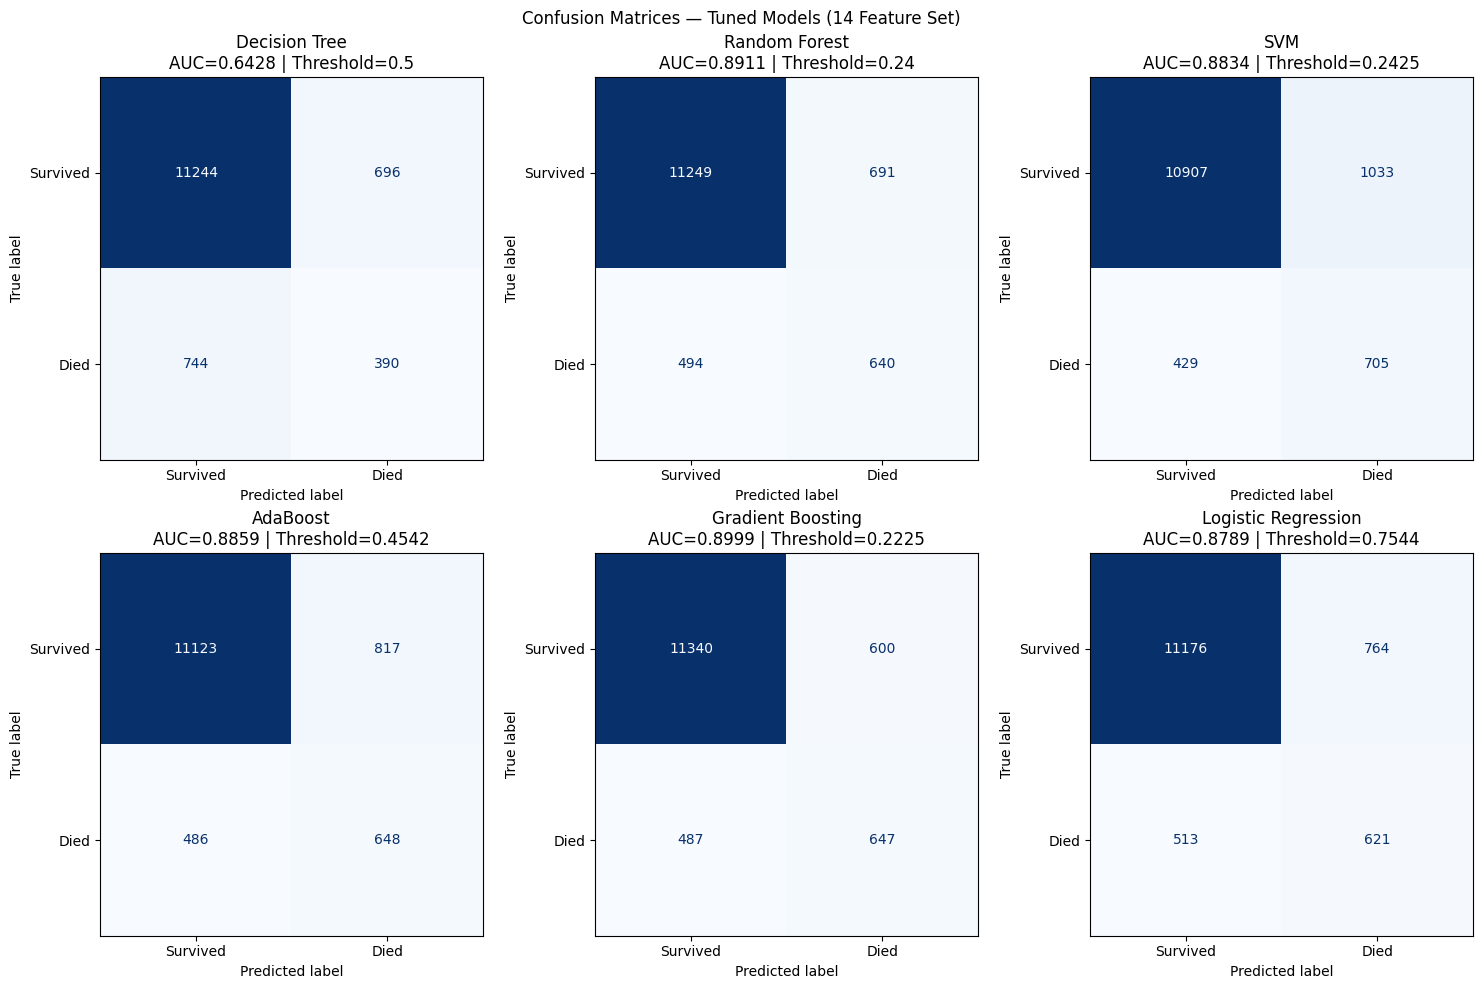

Figure saved as confusion_matrices_tuned.png


In [ ]:
# Plot confusion matrices
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):

    threshold = tuned_thresholds[name]

    # Predicted probabilities
    y_prob = model.predict_proba(x_test_final)[:, 1]

    # Apply tuned threshold
    y_pred = (y_prob >= threshold).astype(int)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Survived", "Died"]
    )

    disp.plot(ax=axes[i], cmap="Blues", colorbar=False)

    auc = roc_auc_score(y_test, y_prob)

    axes[i].set_title(f"{name}\nAUC={auc:.4f} | Threshold={threshold}")


# Final formatting
plt.suptitle("Confusion Matrices — Tuned Models (14 Feature Set)")

plt.tight_layout()

plt.savefig("confusion_matrices_tuned.png", bbox_inches="tight")
plt.show()

print("Figure saved as confusion_matrices_tuned.png")

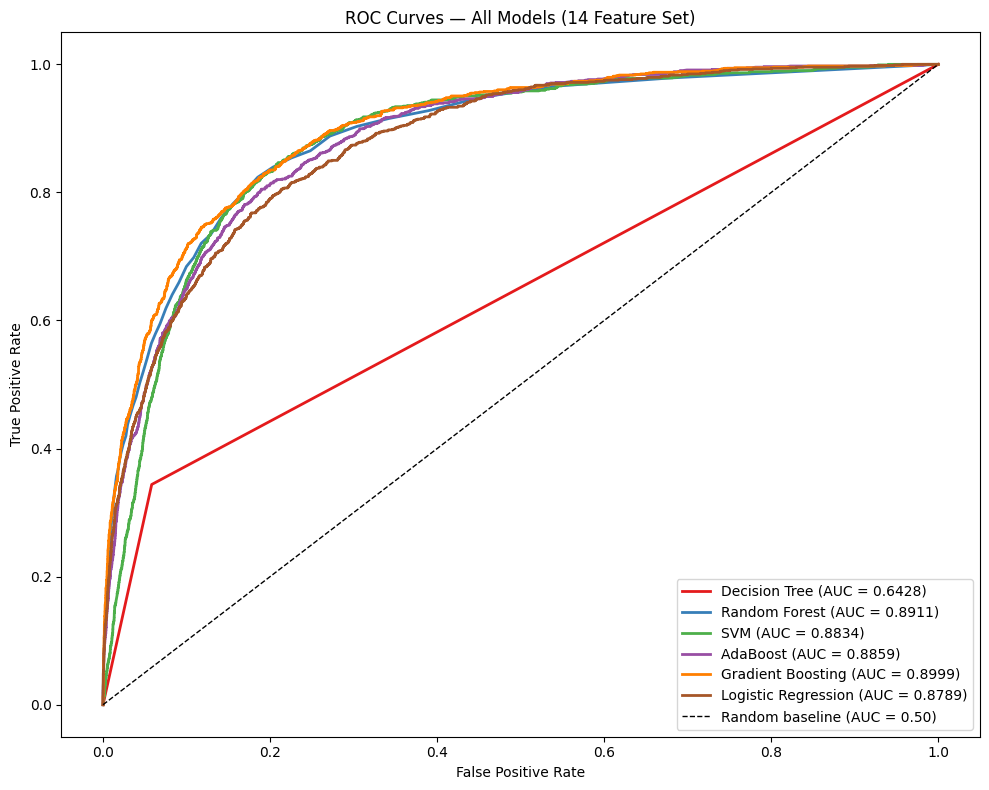

Figure saved as roc_curves.png


In [38]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Plot ROC curves for all models
plt.figure(figsize=(10, 8))

colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#a65628']

for (name, model), color in zip(models.items(), colors):

    y_prob = model.predict_proba(x_test_final)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    plt.plot(fpr, tpr, color=color, linewidth=2, label=f"{name} (AUC = {auc:.4f})")

# Random baseline
plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random baseline (AUC = 0.50)")

# Formatting
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models (14 Feature Set)",)

plt.legend(loc="lower right")

plt.tight_layout()
plt.savefig("roc_curves.png", bbox_inches="tight")

plt.show()
print("Figure saved as roc_curves.png")

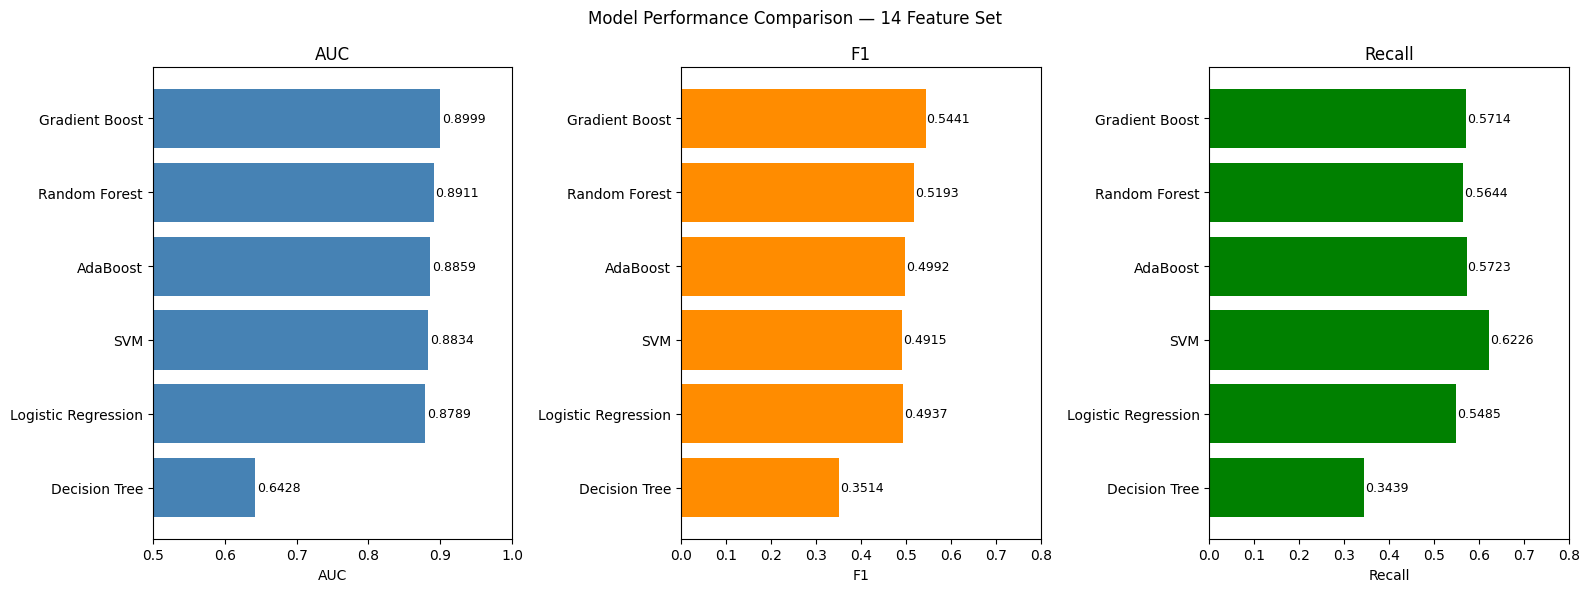

Figure saved as model_comparison.png


In [39]:
import matplotlib.pyplot as plt
import pandas as pd

# Model performance data
metrics_df = pd.DataFrame({
    "Model": ["Gradient Boost", "Random Forest", "AdaBoost", "SVM", "Logistic Regression", "Decision Tree"],
    "AUC": [0.8999, 0.8911, 0.8859, 0.8834, 0.8789, 0.6428],
    "F1": [0.5441, 0.5193, 0.4992, 0.4915, 0.4937, 0.3514],
    "Recall": [0.5714, 0.5644, 0.5723, 0.6226, 0.5485, 0.3439]
}).sort_values("AUC")

# Create plots
fig, axes = plt.subplots(1, 3, figsize=(16, 6)) # to create three columns

plot_info = [
    ("AUC", "steelblue", (0.5, 1.0)),
    ("F1", "darkorange", (0, 0.8)),
    ("Recall", "green", (0, 0.8))
]

for ax, (metric, color, limits) in zip(axes, plot_info):

    ax.barh(metrics_df["Model"], metrics_df[metric], color=color)
    ax.set_xlabel(metric)
    ax.set_title(metric)
    ax.set_xlim(limits)

    for i, value in enumerate(metrics_df[metric]):
        ax.text(value + 0.002, i, f"{value:.4f}", va="center", fontsize=9) #adding the result value at the end of each bar

# Final formatting
plt.suptitle("Model Performance Comparison — 14 Feature Set")

plt.tight_layout()
plt.savefig("model_comparison.png", bbox_inches="tight")
plt.show()
print("Figure saved as model_comparison.png")